# E-field distortion vs nominal PID score comparison

Compare track PID χ² distributions **with** and **without** the double-anode E-field map
applied in `sel_*-updateefield` dataframe production (`chi2_*_new` vs CAF nominal `chi2_*`).

Uses the same χ² extraction helpers as `PID.ipynb` (`avg_chi2`, `VariableConfig` binning).

**Expected input:** `sel_2prong-updateefield` (or `sel_mup-updateefield`) grid output with
`trk1` / `trk2` blocks containing both `chi2_muon` and `chi2_muon_new` (same for protons).
Set `USE_SINGLE_DF_FILE = True` to run on one merged `*.df` file instead of a directory glob.

Re-run df production after the `updateefield` fix in `make_pandora_evtdf` if `evt` tables lack
track columns (older jobs may only contain truth/meta columns).

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import glob as glob_module
import gc
import pickle
from os import makedirs, path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm
from tqdm import tqdm

import sys
sys.path.append("/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana")

from analysis_village.numucc_1p0pi.files_config import save_fig_base_dir
from analysis_village.numucc_1p0pi.makedf.selections import (
    cut_2prong_contained,
    cut_2prong_trackscore,
    cut_2prong_vtxdist,
    evt_has_trk1_trk2,
)
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from makedf.util import avg_chi2 as _raw_avg_chi2
from pyanalib.split_df_helpers import get_n_split

plt.style.use("presentation.mplstyle")
import warnings
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)

## Configuration

In [17]:
DFS_ROOT = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs"

# Grid-output directory from sel_*-updateefield (edit timestamp after new submissions).
SAMPLE_DIR = path.join(DFS_ROOT, "2026_07_09_233831__sel_2prong-mc-BNB_cosmics-efieldvar")

# Set True to read one merged *.df file instead of globbing SAMPLE_DIR.
USE_SINGLE_DF_FILE = False
SAMPLE_DF_FILE = path.join(
    SAMPLE_DIR,
    "2026_07_09_233831__sel_2prong-mc-BNB_cosmics-efieldvar_0.df",
)

if USE_SINGLE_DF_FILE:
    SAMPLE_NAME = path.splitext(path.basename(SAMPLE_DF_FILE))[0]
else:
    SAMPLE_NAME = path.basename(SAMPLE_DIR)

FILENAME_STR = "sel_2prong"  # substring filter for grid *.df files (directory mode only)
N_MAX_FILES = 25          # max number of *.df files to read (directory mode only)
N_MAX_SPLITS = None       # None = all HDF splits per file

DETECTOR = "SBND_Gen1"
TRACKSCORE_TH = 0.5
VTXDIST_TH = 1.2
APPLY_2PRONG_QUAL_CUTS = True

OUT_BASE = path.join(save_fig_base_dir, "systematics-final", "Efield", "PID")
CACHE_DIR = path.join(OUT_BASE, "cache")
FIG_DIR = path.join(OUT_BASE, "plots")
CACHE_PATH = path.join(CACHE_DIR, "efield_pid_hists.pkl")
makedirs(CACHE_DIR, exist_ok=True)
makedirs(FIG_DIR, exist_ok=True)

VERSION_COLORS = {"nominal": "C0", "efield": "C1"}
RUN_ACCUMULATION = True

if USE_SINGLE_DF_FILE:
    print("Mode: single file")
    print("Sample file:", SAMPLE_DF_FILE)
else:
    print("Mode: grid directory")
    print("Sample dir:", SAMPLE_DIR)
print("Sample name:", SAMPLE_NAME)
print("Cache:", CACHE_PATH)
print("Figures:", FIG_DIR)

Sample: /pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_07_09_233831__sel_2prong-mc-BNB_cosmics-efieldvar
Cache: /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/Efield/PID/cache/efield_pid_hists.pkl
Figures: /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/Efield/PID/plots


In [18]:
def _safe_avg_chi2(trk_df, chi2_name):
    try:
        return _raw_avg_chi2(trk_df, chi2_name).to_numpy(dtype=float)
    except Exception:
        return np.array([], dtype=float)


def _per_trk(evt_df, fn):
    out = []
    top_cols = evt_df.columns.get_level_values(0).unique()
    for trk in ("trk1", "trk2"):
        if trk not in top_cols:
            continue
        try:
            vals = np.asarray(fn(evt_df[trk]), dtype=float)
            if vals.ndim == 1:
                out.append(vals)
        except Exception:
            pass
    return np.concatenate(out) if out else np.array([], dtype=float)


def _per_trk_label(evt_df, trk_label, fn):
    if trk_label not in evt_df.columns.get_level_values(0):
        return np.array([], dtype=float)
    try:
        return np.asarray(fn(evt_df[trk_label]), dtype=float)
    except Exception:
        return np.array([], dtype=float)


def validate_evt_df(df, label="evt"):
    if df is None or len(df) == 0:
        raise ValueError(f"{label}: empty dataframe")
    if not evt_has_trk1_trk2(df):
        raise ValueError(
            f"{label}: missing trk1/trk2 columns. "
            "Re-run sel_*-updateefield after the updateefield wiring fix."
        )
    for score in ("chi2_muon", "chi2_muon_new"):
        vals = _per_trk(df, lambda t, s=score: _safe_avg_chi2(t, s))
        if vals.size == 0:
            raise ValueError(f"{label}: could not extract {score}")
    return True


def apply_optional_qual_cuts(df):
    if not APPLY_2PRONG_QUAL_CUTS:
        return df
    if not evt_has_trk1_trk2(df):
        return df.iloc[0:0]
    df = cut_2prong_contained(df, det=DETECTOR)
    df = cut_2prong_trackscore(df, TRACKSCORE_TH)
    df = cut_2prong_vtxdist(df, VTXDIST_TH)
    return df


VAR_DEFS = {
    "chi2_mu_nom": {
        "label": VariableConfig.chi2_mu().var_labels[0] + " (nominal)",
        "bins": np.asarray(VariableConfig.chi2_mu().bins),
        "extract": lambda df: _per_trk(df, lambda t: _safe_avg_chi2(t, "chi2_muon")),
    },
    "chi2_mu_efield": {
        "label": VariableConfig.chi2_mu().var_labels[0] + " (E-field)",
        "bins": np.asarray(VariableConfig.chi2_mu().bins),
        "extract": lambda df: _per_trk(df, lambda t: _safe_avg_chi2(t, "chi2_muon_new")),
    },
    "chi2_p_nom": {
        "label": VariableConfig.chi2_proton().var_labels[0] + " (nominal)",
        "bins": np.asarray(VariableConfig.chi2_proton().bins),
        "extract": lambda df: _per_trk(df, lambda t: _safe_avg_chi2(t, "chi2_proton")),
    },
    "chi2_p_efield": {
        "label": VariableConfig.chi2_proton().var_labels[0] + " (E-field)",
        "bins": np.asarray(VariableConfig.chi2_proton().bins),
        "extract": lambda df: _per_trk(df, lambda t: _safe_avg_chi2(t, "chi2_proton_new")),
    },
}

PAIR_DEFS = [
    ("chi2_mu_nom", "chi2_mu_efield", "chi2_mu"),
    ("chi2_p_nom", "chi2_p_efield", "chi2_proton"),
]

print("Variables:", list(VAR_DEFS.keys()))

Variables: ['chi2_mu_nom', 'chi2_mu_efield', 'chi2_p_nom', 'chi2_p_efield']


In [19]:
def get_sample_df_files():
    """Return *.df paths for the configured sample (directory glob or single file)."""
    if USE_SINGLE_DF_FILE:
        if not SAMPLE_DF_FILE:
            raise ValueError("USE_SINGLE_DF_FILE=True but SAMPLE_DF_FILE is not set")
        if not path.isfile(SAMPLE_DF_FILE):
            raise FileNotFoundError(f"SAMPLE_DF_FILE not found: {SAMPLE_DF_FILE}")
        return [SAMPLE_DF_FILE]

    pattern = path.join(SAMPLE_DIR, f"*{FILENAME_STR}*.df")
    files = sorted(glob_module.glob(pattern))[: int(N_MAX_FILES)]
    if not files:
        raise FileNotFoundError(f"No files for pattern {pattern}")
    return files


def _fill_hists_from_split(df, var_defs, hists):
    if df is None or len(df) == 0:
        return 0
    n = len(df)
    for var_name, cfg in var_defs.items():
        try:
            vals = cfg["extract"](df)
        except Exception:
            continue
        vals = np.asarray(vals, dtype=float)
        vals = vals[np.isfinite(vals)]
        if vals.size == 0:
            continue
        eps = (cfg["bins"][-1] - cfg["bins"][0]) * 1e-9
        vals = np.clip(vals, cfg["bins"][0], cfg["bins"][-1] - eps)
        counts, _ = np.histogram(vals, bins=cfg["bins"])
        hists[var_name] += counts
    return n


def _read_evt_split(file_path, split_idx):
    return pd.read_hdf(file_path, key=f"evt_{split_idx}")


def accumulate_from_sample(var_defs, n_max_splits):
    files = get_sample_df_files()
    desc = path.basename(files[0]) if USE_SINGLE_DF_FILE else path.basename(SAMPLE_DIR)

    hists = {v: np.zeros(len(cfg["bins"]) - 1, dtype=float) for v, cfg in var_defs.items()}
    n_evts = 0
    for fpath in tqdm(files, desc=desc):
        try:
            n_split = get_n_split(fpath)
        except Exception as exc:
            print(f"skip {path.basename(fpath)}: {exc}")
            continue
        n_use = n_split if n_max_splits is None else min(n_split, int(n_max_splits))
        for i in range(n_use):
            try:
                df = _read_evt_split(fpath, i)
            except Exception:
                continue
            df = apply_optional_qual_cuts(df)
            n_evts += _fill_hists_from_split(df, var_defs, hists)
            del df
        gc.collect()
    return hists, n_evts


def save_hists(cache_path, hists, n_evts, var_defs, sample_name):
    payload = {
        "version": 1,
        "sample": sample_name,
        "var_defs": {
            k: {"label": v["label"], "bins": np.asarray(v["bins"])}
            for k, v in var_defs.items()
        },
        "hists": hists,
        "n_evts": n_evts,
    }
    with open(cache_path, "wb") as fh:
        pickle.dump(payload, fh, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Saved cache → {cache_path}")
    return payload


def load_hists(cache_path):
    with open(cache_path, "rb") as fh:
        payload = pickle.load(fh)
    print(
        f"Loaded cache: sample={payload['sample']!r}, "
        f"{len(payload['var_defs'])} variables, {payload['n_evts']:,} events"
    )
    return payload

## Inspect loaded dataframe

Load the first `evt_0` split from the grid output and print column layout before histogram accumulation. Useful to confirm `trk1`/`trk2` and `chi2_*` / `chi2_*_new` are present (does not apply quality cuts or raise on missing tracks).

In [20]:
def print_evt_df_summary(df, label="evt"):
    top_cols = df.columns.get_level_values(0).unique()
    print(f"{label}: {len(df):,} rows, index levels={df.index.names}")
    print(f"  top-level columns ({len(top_cols)}): {list(top_cols)}")
    for trk in ("trk1", "trk2", "slc", "mc"):
        present = trk in top_cols
        print(f"  {trk}: {'present' if present else 'MISSING'}")
        if present and trk.startswith("trk"):
            sub = df[trk].columns
            chi2_cols = [c for c in sub if "chi2" in str(c).lower()]
            suffix = "..." if len(chi2_cols) > 8 else ""
            print(f"    {len(sub)} sub-columns; chi2-related: {chi2_cols[:8]}{suffix}")
    print(f"  evt_has_trk1_trk2: {evt_has_trk1_trk2(df)}")


try:
    _inspect_files = get_sample_df_files()
except FileNotFoundError as exc:
    print(exc)
    loaded_evt_df = None
else:
    _inspect_path = _inspect_files[0]
    loaded_evt_df = _read_evt_split(_inspect_path, 0)
    print(f"File: {_inspect_path}")
    print("HDF key: evt_0\n")
    print_evt_df_summary(loaded_evt_df, label=SAMPLE_NAME)
    print("\nFirst rows:")
    loaded_evt_df.head()

File: /pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_07_09_233831__sel_2prong-mc-BNB_cosmics-efieldvar/sel_2prong-mc-BNB_cosmics-efieldvar_0.df
HDF key: evt_0

2026_07_09_233831__sel_2prong-mc-BNB_cosmics-efieldvar: 3,758 rows, index levels=['__ntuple', None]
  top-level columns (52): ['entry', 'rec.mc.nu..index', 'E', 'baseline', 'time', 'bjorkenX', 'inelasticityY', 'Q2', 'w', 'momentum', 'position', 'pdg', 'iscc', 'genie_mode', 'genweight', 'parent_pdg', 'parent_dcy_E', 'genie_evtrec_idx', 'max_proton_ke', 'nn', 'np', 'nmu', 'npi', 'npi0', 'ng', 'nk', 'nk0', 'nsm', 'nsp', 'nmu_27MeV', 'np_20MeV', 'np_50MeV', 'npi_30MeV', 'nn_0MeV', 'nmu_220MeVc', 'nmu_100MeVc', 'np_300MeVc', 'np_200MeVc', 'npi_70MeVc', 'mu', 'cpi', 'p', 'e', 'ind', 'pot', 'nbnbinfo', 'first_in_subrun', 'ismc', 'run', 'subrun', 'ngenevt', 'evt']
  trk1: MISSING
  trk2: MISSING
  slc: MISSING
  mc: MISSING
  evt_has_trk1_trk2: False

First rows:


In [21]:
loaded_evt_df

entry rec.mc.nu..index         E    baseline      time  bjorkenX  \
                                                                               
                                                                               
__ntuple                                                                       
0        0      0                0  2.702485   84.799538  0.436419  0.092515   
         1      0                1  2.770631  120.183342  1.219060  0.119824   
         2      0                2  1.248443  106.071991  0.634706  0.909660   
         3      1                0  1.247357   90.650215  1.810611  0.104762   
         4      2                0  0.654835  110.643219  1.790001  1.180239   
...           ...              ...       ...         ...       ...       ...   
124      18    10                0  0.411440  118.945290  1.021826  0.534934   
         19    10                1  0.419852  106.635078  1.722065  0.684466   
         20    10                2  1.530458  125.715324  0.931304  0.464328   
         21    11                0  0.398253  105.534332  1.264714  0.780408   
         22    12                0  1.025577  120.317108  1.479826  1.341108   

            inelasticityY        Q2         w  momentum  ...         p ind  \
                                                      x  ...       dir       
                                                         ...         z       
__ntuple                                                 ...                 
0        0       0.341363  0.160270  1.566416 -0.220374  ...  0.713574   0   
         1       0.843204  0.525669  2.177824 -0.047093  ... -0.510962   1   
         2       0.065927  0.140596  0.946325 -0.003710  ...  0.356542   2   
         3       0.639366  0.156893  1.490733  0.025495  ...  0.744839   0   
         4       0.322176  0.467577  0.900091  0.009323  ...  0.180742   0   
...                   ...       ...       ...       ...  ...       ...  ..   
124      18      0.257714  0.106513  0.987000  0.001260  ...  0.785587   0   
         19      0.517507  0.279269  1.005141  0.010783  ...  0.874178   1   
         20      0.828679  1.105835  1.468781  0.102059  ...  0.570818   2   
         21      0.305454  0.178273  0.965262  0.008767  ...  0.493701   0   
         22      0.176867  0.456811  0.874860  0.017671  ...  0.764825   0   

                      pot nbnbinfo first_in_subrun ismc   run subrun ngenevt  \
                                                                               
                                                                               
__ntuple                                                                       
0        0   1.282054e+15        0               1    1  1975     97     100   
         1   1.282054e+15        0               1    1  1975     97     100   
         2   1.282054e+15        0               1    1  1975     97     100   
         3   0.000000e+00        0               0    1  1975     97     100   
         4   0.000000e+00        0               0    1  1975     97     100   
...                   ...      ...             ...  ...   ...    ...     ...   
124      18  0.000000e+00        0               0    1  3211     76     100   
         19  0.000000e+00        0               0    1  3211     76     100   
         20  0.000000e+00        0               0    1  3211     76     100   
         21  0.000000e+00        0               0    1  3211     76     100   
         22  0.000000e+00        0               0    1  3211     76     100   

            evt  
                 
                 
__ntuple         
0        0    4  
         1    4  
         2    4  
         3   10  
         4   12  
...          ..  
124      18  83  
         19  83  
         20  83  
         21  95  
         22  96  

[3758 rows x 120 columns]

In [6]:
if RUN_ACCUMULATION:
    hists, n_evts = accumulate_from_sample(VAR_DEFS, N_MAX_SPLITS)
    print(f"events after cuts: {n_evts:,}")
    save_hists(CACHE_PATH, hists, n_evts, VAR_DEFS, SAMPLE_NAME)
else:
    print("Skipping accumulation; will load cache in next cell.")

2026_07_09_210347__sel_2prong-mc-BNB_cosmics-efieldvar: 100%|██████████| 25/25 [00:08<00:00,  2.80it/s]

events after cuts: 0
Saved cache → /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/Efield/PID/cache/efield_pid_hists.pkl


In [7]:
if not RUN_ACCUMULATION:
    _payload = load_hists(CACHE_PATH)
    hists = _payload["hists"]
    n_evts = _payload["n_evts"]
    PLOT_VAR_DEFS = _payload["var_defs"]
else:
    PLOT_VAR_DEFS = {
        k: {"label": v["label"], "bins": np.asarray(v["bins"])}
        for k, v in VAR_DEFS.items()
    }

print(f"{SAMPLE_NAME}: {n_evts:,} events")

2026_07_09_210347__sel_2prong-mc-BNB_cosmics-efieldvar: 0 events


  saved pid_1d_chi2_mu.pdf / .png


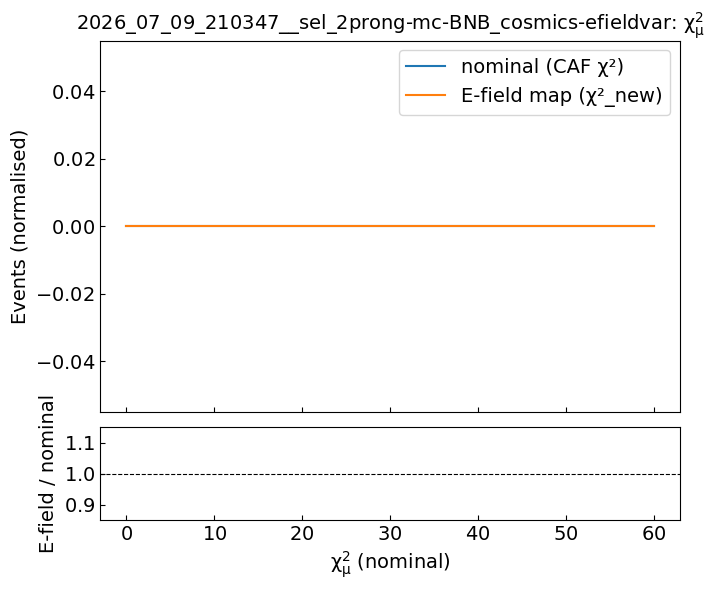

  saved pid_1d_chi2_proton.pdf / .png


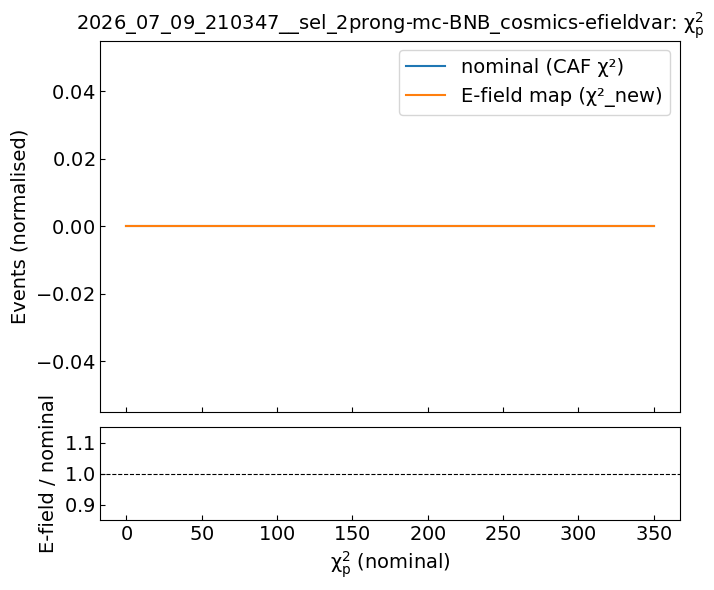

In [8]:
def save_fig(fig, name, fig_dir=FIG_DIR, dpi=150):
    makedirs(fig_dir, exist_ok=True)
    for ext in ("pdf", "png"):
        fig.savefig(path.join(fig_dir, f"{name}.{ext}"), bbox_inches="tight", dpi=dpi)
    print(f"  saved {name}.pdf / .png")


def plot_nominal_vs_efield_1d(
    sample_name,
    nom_key,
    efield_key,
    var_defs,
    hists,
    ratio=True,
    normalize=True,
    title=None,
):
    bins = np.asarray(var_defs[nom_key]["bins"])
    nom = hists[nom_key].astype(float)
    ef = hists[efield_key].astype(float)
    if normalize:
        nom_tot, ef_tot = nom.sum(), ef.sum()
        if nom_tot > 0:
            nom = nom / nom_tot
        if ef_tot > 0:
            ef = ef / ef_tot

    if ratio:
        fig, (ax_top, ax_bot) = plt.subplots(
            2, 1, figsize=(7, 6), sharex=True, gridspec_kw={"height_ratios": [4, 1]}
        )
        fig.subplots_adjust(hspace=0.08)
    else:
        fig, ax_top = plt.subplots(figsize=(7, 4.5))
        ax_bot = None

    ax_top.step(
        bins, np.append(nom, nom[-1]), where="post",
        label="nominal (CAF χ²)", color=VERSION_COLORS["nominal"], linewidth=1.5,
    )
    ax_top.step(
        bins, np.append(ef, ef[-1]), where="post",
        label="E-field map (χ²_new)", color=VERSION_COLORS["efield"], linewidth=1.5,
    )
    ax_top.set_ylabel("Events (normalised)" if normalize else "Events")
    ax_top.legend(frameon=True)
    ax_top.set_title(title or f"{sample_name}: {var_defs[nom_key]['label'].split('(')[0].strip()}")

    if ratio and ax_bot is not None:
        with np.errstate(divide="ignore", invalid="ignore"):
            rat = np.where(nom > 0, ef / nom, np.nan)
        ax_bot.axhline(1.0, color="k", linewidth=0.8, linestyle="--")
        ax_bot.step(bins, np.append(rat, rat[-1]), where="post", color=VERSION_COLORS["efield"])
        ax_bot.set_ylabel("E-field / nominal")
        ax_bot.set_xlabel(var_defs[nom_key]["label"])
        ax_bot.set_ylim(0.85, 1.15)
    else:
        ax_top.set_xlabel(var_defs[nom_key]["label"])

    fig.tight_layout()
    return fig


for nom_key, ef_key, tag in PAIR_DEFS:
    fig = plot_nominal_vs_efield_1d(
        SAMPLE_NAME, nom_key, ef_key, PLOT_VAR_DEFS, hists, ratio=True
    )
    save_fig(fig, f"pid_1d_{tag}")
    plt.show()
    plt.close(fig)

## 2D PID planes (μ vs p χ²)

Side-by-side 2D histograms for nominal and E-field-redone scores (`PID.ipynb` style).

In [9]:
def load_evt_subset(n_files=5, n_splits=1):
    """Load evt splits from the configured sample for in-memory plots."""
    files = get_sample_df_files()[:n_files]
    frames = []
    for fpath in files:
        n_split = min(get_n_split(fpath), n_splits)
        for i in range(n_split):
            frames.append(_read_evt_split(fpath, i))
    if not frames:
        raise FileNotFoundError(f"No evt splits found for configured sample ({SAMPLE_NAME})")
    df = pd.concat(frames, axis=0, sort=False)
    validate_evt_df(df, label=SAMPLE_NAME)
    return apply_optional_qual_cuts(df)


def plot_pid_plane_2d(evt_df, trk_label, chi2_mu_tag, chi2_p_tag, title_prefix=""):
    mu = _per_trk_label(evt_df, trk_label, lambda t: _safe_avg_chi2(t, chi2_mu_tag))
    pp = _per_trk_label(evt_df, trk_label, lambda t: _safe_avg_chi2(t, chi2_p_tag))
    mask = np.isfinite(mu) & np.isfinite(pp)
    mu, pp = mu[mask], pp[mask]

    cfg_mu = VariableConfig.chi2_mu()
    cfg_p = VariableConfig.chi2_proton()

    fig, ax = plt.subplots(figsize=(6, 5))
    h = ax.hist2d(
        mu, pp,
        bins=[cfg_mu.bins, cfg_p.bins],
        cmap="viridis",
        norm=LogNorm(),
    )
    fig.colorbar(h[3], ax=ax, label="entries")
    ax.set_xlabel(cfg_mu.var_labels[0])
    ax.set_ylabel(cfg_p.var_labels[0])
    ax.set_title(f"{title_prefix}{trk_label}: {chi2_mu_tag} vs {chi2_p_tag}")
    fig.tight_layout()
    return fig


evt_df = load_evt_subset(n_files=5, n_splits=1)
print(f"loaded {len(evt_df):,} events from {SAMPLE_NAME}")

for trk in ("trk1", "trk2"):
    for chi2_mu_tag, chi2_p_tag, tag in (
        ("chi2_muon", "chi2_proton", "nominal"),
        ("chi2_muon_new", "chi2_proton_new", "efield"),
    ):
        fig = plot_pid_plane_2d(
            evt_df, trk, chi2_mu_tag, chi2_p_tag,
            title_prefix=f"{SAMPLE_NAME} / ",
        )
        save_fig(fig, f"pid_2d_{trk}_{tag}")
        plt.show()
        plt.close(fig)

ValueError: 2026_07_09_210347__sel_2prong-mc-BNB_cosmics-efieldvar: missing trk1/trk2 columns. Re-run sel_*-updateefield after the updateefield wiring fix.

## Per-track Δχ² (E-field − nominal)

In [ ]:
def paired_delta_chi2(evt_df, trk_label, par):
    nom = _per_trk_label(evt_df, trk_label, lambda t, p=par: _safe_avg_chi2(t, f"chi2_{p}"))
    ef = _per_trk_label(evt_df, trk_label, lambda t, p=par: _safe_avg_chi2(t, f"chi2_{p}_new"))
    mask = np.isfinite(nom) & np.isfinite(ef)
    return ef[mask] - nom[mask]


evt_df = load_evt_subset(n_files=8, n_splits=1)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, trk in zip(axes, ("trk1", "trk2")):
    d_mu = paired_delta_chi2(evt_df, trk, "muon")
    d_p = paired_delta_chi2(evt_df, trk, "proton")
    if d_mu.size:
        ax.hist(d_mu, bins=60, histtype="step", label=r"$\Delta\chi^2_\mu$")
    if d_p.size:
        ax.hist(d_p, bins=60, histtype="step", label=r"$\Delta\chi^2_p$")
    ax.axvline(0, color="k", linewidth=0.8, linestyle="--")
    ax.set_xlabel(r"$\chi^2_\mathrm{efield} - \chi^2_\mathrm{nominal}$")
    ax.set_ylabel("tracks")
    ax.set_title(trk)
    ax.legend()
fig.suptitle(f"{SAMPLE_NAME}: per-track χ² shift from E-field map")
fig.tight_layout()
save_fig(fig, "pid_delta")
plt.show()
plt.close(fig)